In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
from google.colab import files
uploaded = files.upload()

Saving genre popularity over time.csv to genre popularity over time (1).csv
Saving monthly engagement trends.csv to monthly engagement trends (1).csv
Saving peak movie rating periods.csv to peak movie rating periods (1).csv


In [20]:
import os

os.rename("Genres producing the highest rated movies (1).csv", "genres_highest_rated.csv")
os.rename("genres producing the lowest rated movies (1).csv", "genres_lowest_rated.csv")
os.rename("tags are associated with highly rated movies (1).csv", "tags_high_rating.csv")
os.rename("top 5 most popular movie genres.csv", "top_genres.csv")
os.rename("top 5 tags.csv", "top_tags.csv")

In [21]:
import pandas as pd

high_genres = pd.read_csv("genres_highest_rated.csv", header=None)
low_genres = pd.read_csv("genres_lowest_rated.csv", header=None)
tags_high = pd.read_csv("tags_high_rating.csv", header=None)
top_genres = pd.read_csv("top_genres.csv", header=None)
top_tags = pd.read_csv("top_tags.csv", header=None)

In [34]:
genre_time = pd.read_csv("genre popularity over time (1).csv")
monthly_engagement = pd.read_csv("monthly engagement trends (1).csv")
peak_ratings = pd.read_csv("peak movie rating periods (1).csv")

print(genre_time.head())
print(monthly_engagement.head())
print(peak_ratings.head())

   1995     Crime  6
0  1995    Comedy  6
1  1995  Thriller  6
2  1995     Drama  3
3  1995   Mystery  3
4  1995   Romance  3
   1995  1     2       30
0  1996  1     6      333
1  1996  2    24     3189
2  1996  3   242    69687
3  1996  4  1259   404994
4  1996  5  3530  1463730
   1995       3.7        30
0  2013  3.649868   5039589
1  2012  3.627754   6157005
2  1999  3.612539   8979747
3  2020  3.606723  15205389
4  1997  3.605190   5253993


In [35]:
genre_time.columns = ["Year", "Genre", "NumRatings"]
monthly_engagement.columns = ["Year", "Month", "UnknownMetric", "TotalRatings"]
peak_ratings.columns = ["Year", "AvgRating", "NumRatings"]

In [36]:
genre_time["NumRatings"] = pd.to_numeric(genre_time["NumRatings"], errors="coerce")

monthly_engagement["TotalRatings"] = pd.to_numeric(monthly_engagement["TotalRatings"], errors="coerce")

peak_ratings["AvgRating"] = pd.to_numeric(peak_ratings["AvgRating"], errors="coerce")

In [22]:
high_genres.columns = ["Genre", "AvgRating", "Count"]
low_genres.columns = ["Genre", "AvgRating", "Count"]

tags_high.columns = ["Tag", "AvgRating", "Count"]

top_genres.columns = ["Count", "Genre"]

top_tags.columns = ["Count", "Tag"]

In [27]:
print(high_genres.columns)
print(low_genres.columns)
print(tags_high.columns)
print(top_genres.columns)
print(top_tags.columns)

Index(['Genre', 'AvgRating', 'Count'], dtype='object')
Index(['Genre', 'AvgRating', 'Count'], dtype='object')
Index(['Tag', 'AvgRating', 'Count'], dtype='object')
Index(['Count', 'Genre'], dtype='object')
Index(['Count', 'Tag'], dtype='object')


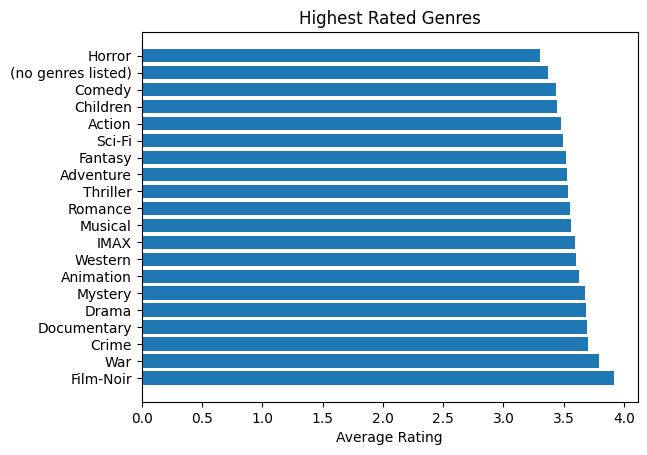

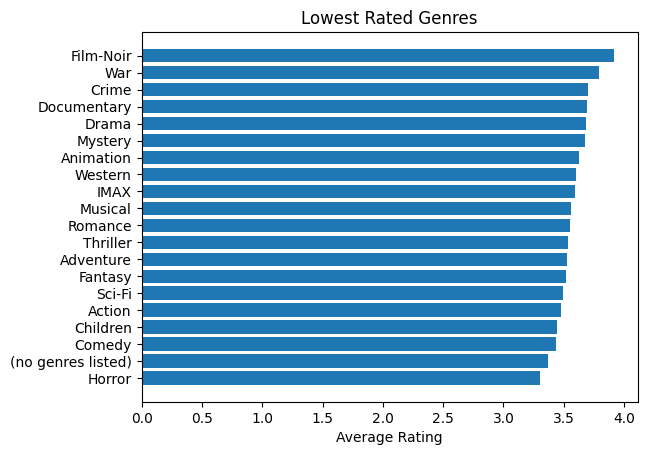

In [23]:
plt.figure()
plt.barh(high_genres["Genre"], high_genres["AvgRating"])
plt.title("Highest Rated Genres")
plt.xlabel("Average Rating")
plt.show()

plt.figure()
plt.barh(low_genres["Genre"], low_genres["AvgRating"])
plt.title("Lowest Rated Genres")
plt.xlabel("Average Rating")
plt.show()

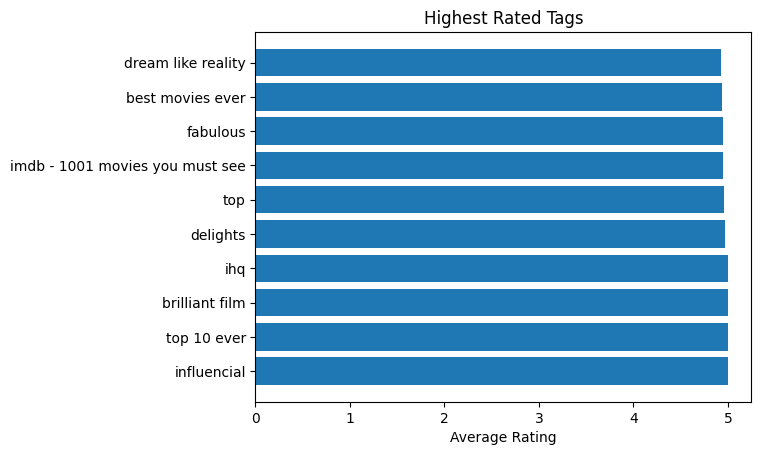

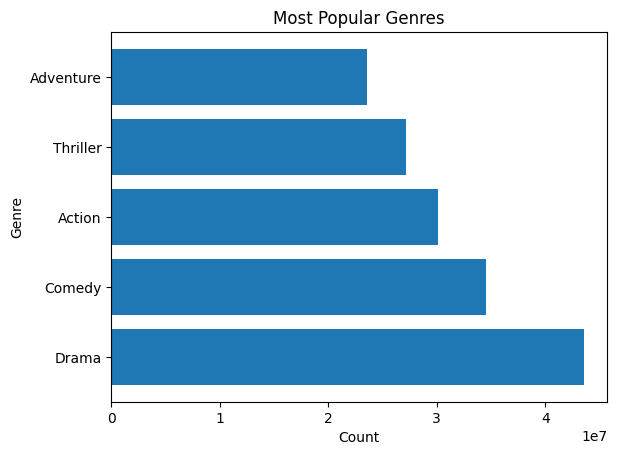

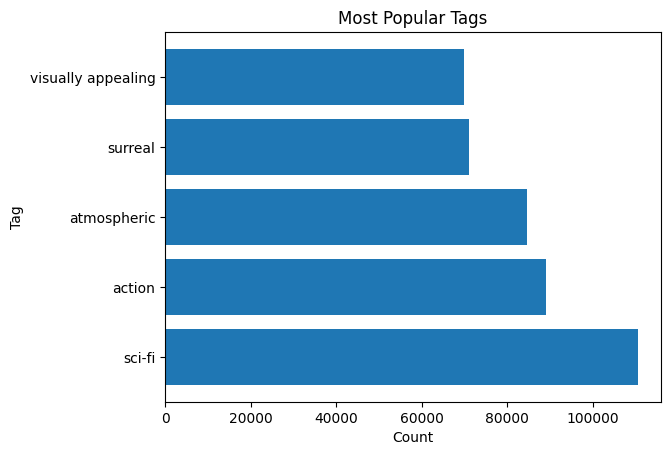

In [30]:

plt.figure()
plt.barh(tags_high["Tag"], tags_high["AvgRating"])
plt.title("Highest Rated Tags")
plt.xlabel("Average Rating")
plt.show()

plt.figure()
plt.barh(top_genres["Genre"], top_genres["Count"])
plt.title("Most Popular Genres")
plt.ylabel("Genre")
plt.xlabel("Count")
plt.show()

plt.figure()
plt.barh(top_tags["Tag"], top_tags["Count"])
plt.title("Most Popular Tags")
plt.ylabel("Tag")
plt.xlabel("Count")
plt.show()

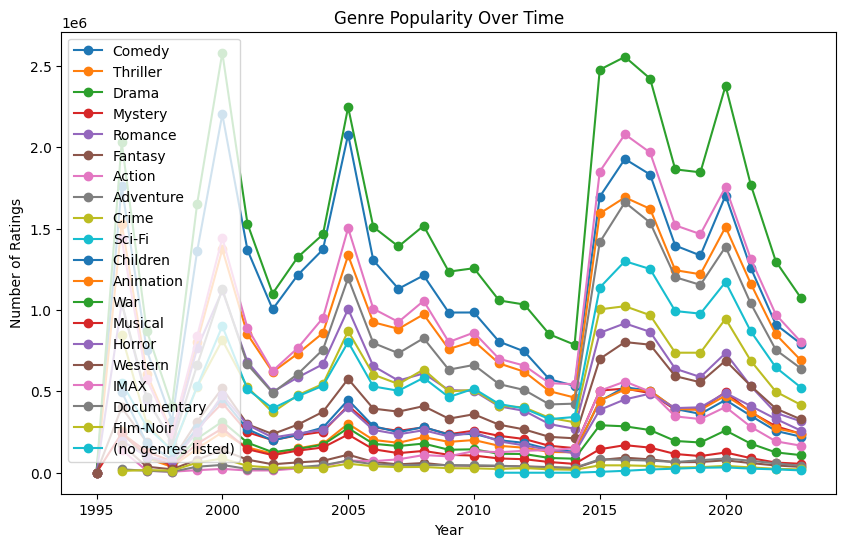

In [37]:

plt.figure(figsize=(10,6))

for genre in genre_time["Genre"].unique():
    subset = genre_time[genre_time["Genre"] == genre]
    plt.plot(subset["Year"], subset["NumRatings"], marker='o', label=genre)

plt.title("Genre Popularity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.legend()
plt.show()

In [41]:
peak_ratings.columns

Index(['Year', 'AvgRating', 'NumRatings'], dtype='object')

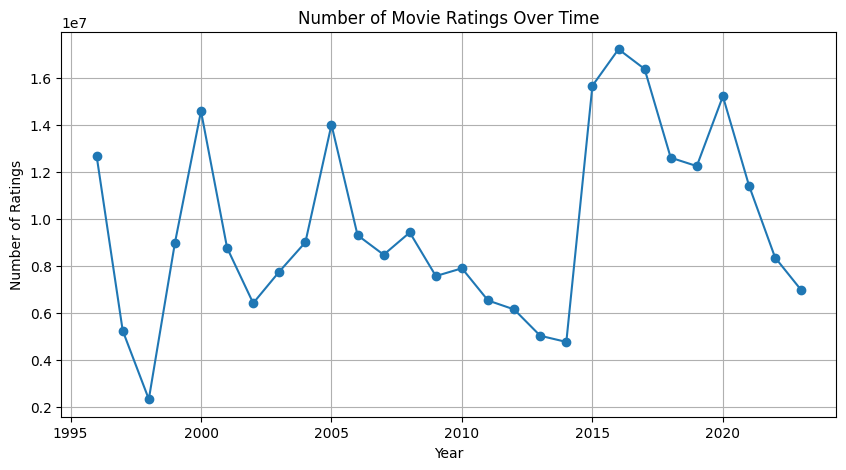

In [44]:

peak_ratings = peak_ratings.sort_values("Year")

plt.figure(figsize=(10,5))

plt.plot(
    peak_ratings["Year"],
    peak_ratings["NumRatings"],
    marker="o"
)

plt.title("Number of Movie Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.grid(True)

plt.show()

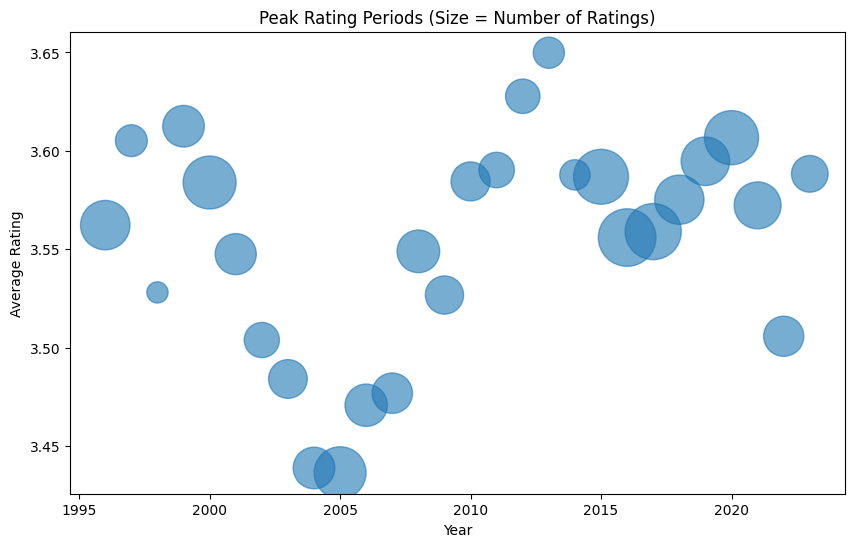

In [45]:
plt.figure(figsize=(10,6))

plt.scatter(
    peak_ratings["Year"],
    peak_ratings["AvgRating"],
    s=peak_ratings["NumRatings"] / 10000,  # scale bubble size
    alpha=0.6
)

plt.title("Peak Rating Periods (Size = Number of Ratings)")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()